**Introduction au Deep Learning avec l'application de bibliothèques PyTorch, TensorFlow...**

In [4]:
import numpy as np
import matplotlib.pyplot as plt


In [6]:
!pip install torch torchvision torchaudio --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_curand_cu12-10.3.9.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cusolver_cu12-11.7.3.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cusparse_cu12-12.5.8.93-py3-none-

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [49]:
import torch
x = torch.tensor([[2.0], [4.0], [5.5], [7.8]])
y_real = torch.tensor([[10.0], [20.0], [27.5], [39.0]])
# y = 5x

print("Shape of X: {}".format(x.shape))
print("Shape of Y: {}".format(y_real.shape))

Shape of X: torch.Size([4, 1])
Shape of Y: torch.Size([4, 1])


In [50]:
#Weight Definition
w = torch.tensor([[0.5]], requires_grad = True)

print("Initial Weight {}".format(w.item()))

Initial Weight 0.5


In [51]:
#GradientDescent Definition
optimizer = torch.optim.SGD([w], lr=0.01)

In [52]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [53]:
epochs = 10

In [54]:
 
loss_history = []
weights_history = []
for epoch in range(epochs):
   
    
    y_pred = torch.matmul(x, w)
    
    loss = torch.mean((y_pred - y_real)**2)
    
    loss_history.append(loss.item())
    weights_history.append(w.item())
    
    loss.backward()
    
    optimizer.step()
    
    optimizer.zero_grad()
    
    if (epoch + 1)%2 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Erreur (Loss) : {loss.item():.4f}")
        loss_.append(loss.item())
        weights_.append(w.item())
        
    

Epoch 2/10 - Erreur (Loss) : 111.1428
Epoch 4/10 - Erreur (Loss) : 4.3407
Epoch 6/10 - Erreur (Loss) : 0.1695
Epoch 8/10 - Erreur (Loss) : 0.0066
Epoch 10/10 - Erreur (Loss) : 0.0003


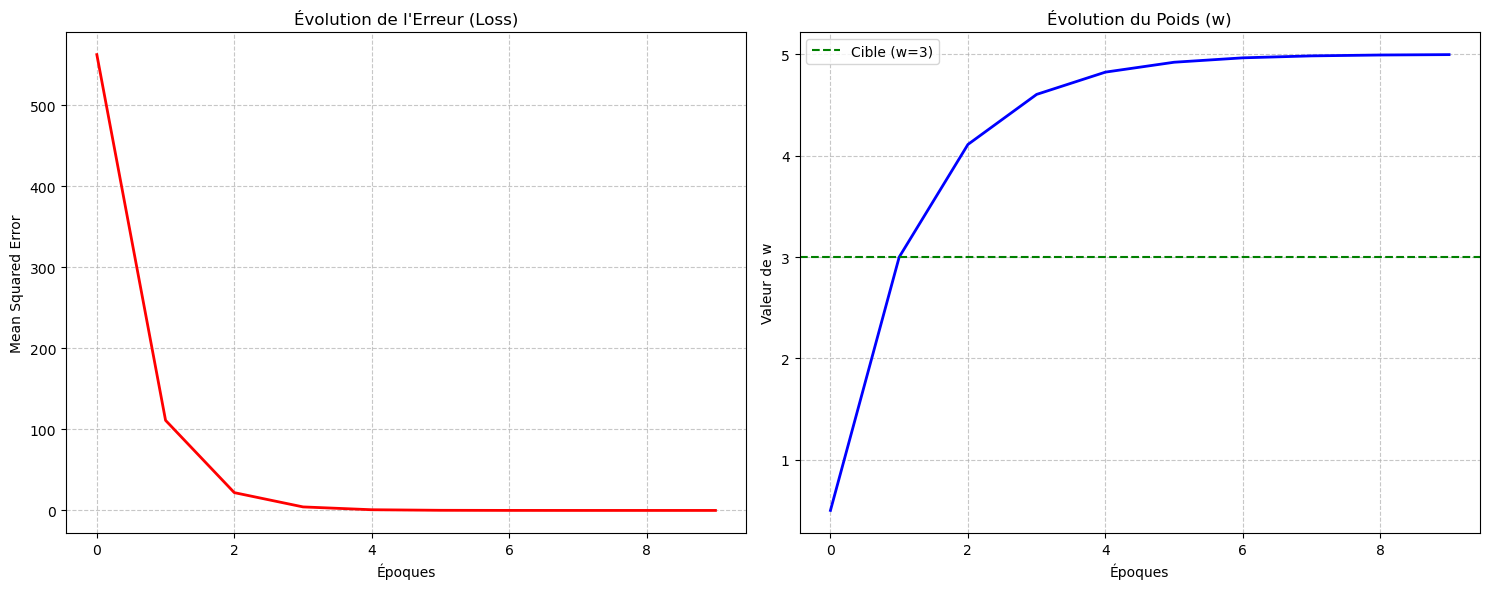

In [55]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


ax1.plot(range(epochs), loss_history, color='red', lw=2)
ax1.set_title('Évolution de l\'Erreur (Loss)')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Mean Squared Error')
ax1.grid(True, linestyle='--', alpha=0.7)


ax2.plot(range(epochs), weights_history, color='blue', lw=2)
ax2.axhline(y=3.0, color='green', linestyle='--', label='Cible (w=3)') 
ax2.set_title('Évolution du Poids (w)')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Valeur de w')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() 
plt.show()